In [1]:
library(tidyverse)
library(pheatmap)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
gns <- read_csv("files_marzo/justDEGs_bp_mock_diff_V_mock_mesc_deseq_results.csv")
cnt <- read_csv("files_marzo//mock_diff_V_mock_mesc.csv_norm_counts.csv")

Rows: 231 Columns: 1
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): V1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 48440 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): V1
dbl (6): DIFF_MOCK_1, DIFF_MOCK_2, DIFF_MOCK_3, MESC_MOCK_1, MESC_MOCK_2, ME...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
glimpse(gns)
glimpse(cnt)

Rows: 231
Columns: 1
$ V1 <chr> "ENSMUSG00000050272.9", "ENSMUSG00000020704.13", "ENSMUSG0000003233…
Rows: 48,440
Columns: 7
$ DIFF_MOCK_1 <dbl> 0.00000, 0.00000, 11.25998, 0.00000, 0.00000, 0.00000, 0.0…
$ DIFF_MOCK_2 <dbl> 0.000000, 0.000000, 2.290105, 0.000000, 0.000000, 0.000000…
$ DIFF_MOCK_3 <dbl> 0.000000, 0.000000, 16.978874, 0.000000, 0.000000, 0.00000…
$ MESC_MOCK_1 <dbl> 0.000000, 0.000000, 2.752620, 0.000000, 0.000000, 0.000000…
$ MESC_MOCK_2 <dbl> 0.0000000, 0.0000000, 0.0000000, 0.0000000, 0.0000000, 0.0…
$ MESC_MOCK_3 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00…
$ V1          <chr> "ENSMUSG00000102693.1", "ENSMUSG00000064842.1", "ENSMUSG00…


In [4]:
cnt2 <- cnt |> mutate(sumcounts = DIFF_MOCK_1+ DIFF_MOCK_2 + DIFF_MOCK_3+ MESC_MOCK_1 + MESC_MOCK_2 + MESC_MOCK_3 ) |> 
    filter(sumcounts != 0) |>
    select(!sumcounts)
glimpse(cnt2)

Rows: 30,782
Columns: 7
$ DIFF_MOCK_1 <dbl> 11.259977, 135.119719, 0.000000, 0.000000, 1321.170586, 0.…
$ DIFF_MOCK_2 <dbl> 2.290105, 119.085449, 0.000000, 0.000000, 981.309899, 9.16…
$ DIFF_MOCK_3 <dbl> 16.978874, 120.267022, 0.000000, 2.829812, 1116.360947, 11…
$ MESC_MOCK_1 <dbl> 2.752620, 53.400828, 1.651572, 0.000000, 1595.418561, 8.80…
$ MESC_MOCK_2 <dbl> 0.000000e+00, 7.831481e+01, 0.000000e+00, 0.000000e+00, 1.…
$ MESC_MOCK_3 <dbl> 0.000000, 78.671463, 0.000000, 0.000000, 1506.923493, 11.3…
$ V1          <chr> "ENSMUSG00000051951.5", "ENSMUSG00000103147.1", "ENSMUSG00…


In [5]:
hm <- cnt2 |> filter(V1 %in% gns$V1)
hmnams <- as.vector(hm$V1)
hm$V1 <- NULL
hm <- as.matrix(hm)
rownames(hm) <- hmnams

pdf 
  2

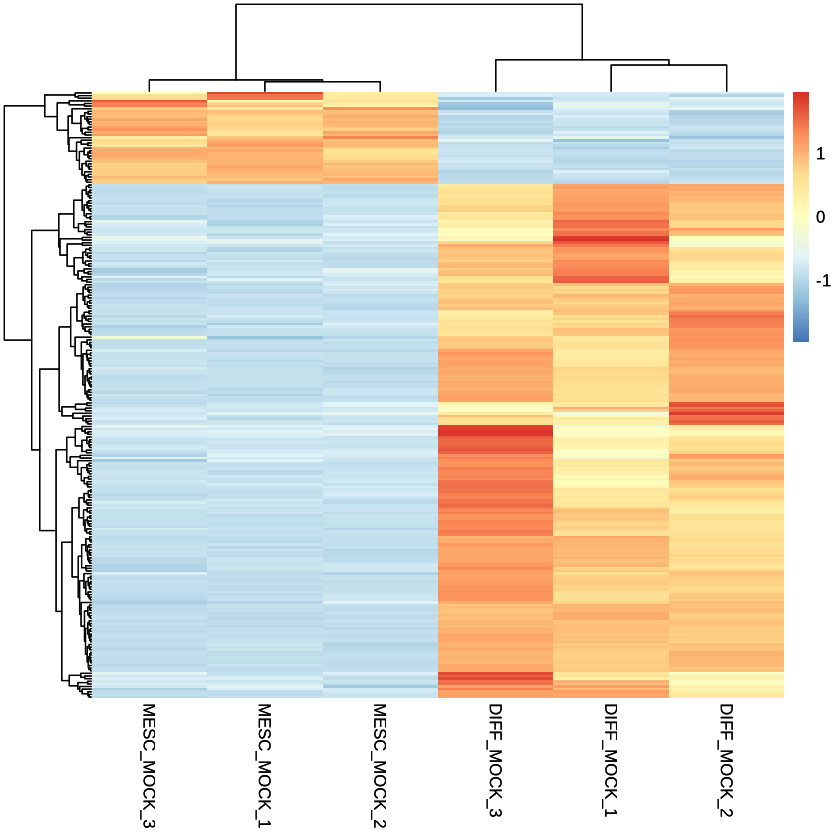

In [6]:
plt <- pheatmap(hm,
         scale= "row", show_rownames = F, cluster_cols= T,cluster_rows = T, border_color =NA , threeheight_row = 0
        )

plt

pdf("heatmap3.pdf", width = 8, height = 12)
plt
dev.off()

In [7]:
glimpse(hm)


 num [1:231, 1:6] 2526 78.8 93.8 748.8 5669.4 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:231] "ENSMUSG00000026211.17" "ENSMUSG00000026227.11" "ENSMUSG00000026247.13" "ENSMUSG00000014602.15" ...
  ..$ : chr [1:6] "DIFF_MOCK_1" "DIFF_MOCK_2" "DIFF_MOCK_3" "MESC_MOCK_1" ...


In [8]:
#write(gns$geneId[!(gns$geneId %in% as.vector(cnt2$V1))], "nograficables.txt")